# TP2 -- Clasificacion Supervisada: Modelos

**Materia:** 72.75 Aprendizaje Automatico (Machine Learning) -- ITBA

Importa los datos limpios de `01_limpieza.ipynb` (`data/processed/train.csv` y `data/processed/test.csv`).
Entrena 5 clasificadores con k-fold CV estratificado, ajusta hiperparametros con curvas de validacion,
compara modelos y evalua el mejor en el test set.

**Para cambiar que modelos correr:** modificar `MODELS_TO_RUN` en la celda CONFIG.

## CONFIG -- modificar aqui

In [16]:
# ============================================================
# CONFIG
# ============================================================
MODELS_TO_RUN = ["naive_bayes", "lda", "svm", "knn", "rf"]  # subset o todos

METRICS       = ["recall", "roc_auc"]   # recall: minimizar FN clinicos; roc_auc: ranking threshold-free
CV_FOLDS      = 5
RANDOM_STATE  = 42
OUTPUT_DIR    = "outputs"

TRAIN_PATH    = "data/processed/train.csv"
TEST_PATH     = "data/processed/test.csv"
print("ok!")

ok!


## Imports

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     validation_curve, GridSearchCV)
from sklearn.metrics         import (
    recall_score, roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

print("Imports OK")

## Registro de modelos e hiperparametros

In [ ]:
MODEL_REGISTRY = {
    "naive_bayes": GaussianNB(),
    "lda":         LinearDiscriminantAnalysis(),
    "svm":         SVC(probability=True, random_state=RANDOM_STATE),
    "knn":         KNeighborsClassifier(),
    "rf":          RandomForestClassifier(random_state=RANDOM_STATE),
}

MODEL_LABELS = {
    "naive_bayes": "Naive Bayes",
    "lda":         "LDA",
    "svm":         "SVM",
    "knn":         "KNN",
    "rf":          "Random Forest",
}

METRIC_LABELS = {
    "recall":   "Recall (Sensibilidad)  TP / (TP + FN)",
    "roc_auc":  "ROC-AUC  — Área bajo la curva ROC",
    "f1":       "F1-Score  — Media armónica precisión/recall",
    "accuracy": "Accuracy  — Fracción de predicciones correctas",
}

# Curvas de validación 1D (un parámetro a la vez)
VALIDATION_CURVES = {
    "svm": [
        ("classifier__C",      np.logspace(-3, 3, 10), "C (regularización)",        True),
    ],
    "knn": [
        ("classifier__n_neighbors", np.arange(1, 31), "k (número de vecinos)",      False),
    ],
    "rf":  [
        ("classifier__max_depth",   np.arange(1, 16), "Profundidad máxima del árbol", False),
    ],
}

# Grid 2D para modelos con múltiples hiperparámetros
PARAM_GRIDS_2D = {
    "svm": {
        "grid":   {"classifier__C":      np.logspace(-2, 3, 7),
                   "classifier__kernel": ["linear", "rbf", "poly"]},
        "param1": "classifier__C",
        "param2": "classifier__kernel",
        "label1": "C (regularización)",
        "label2": "Kernel",
    },
    "knn": {
        "grid":   {"classifier__n_neighbors": list(range(1, 22, 2)),
                   "classifier__weights":     ["uniform", "distance"]},
        "param1": "classifier__n_neighbors",
        "param2": "classifier__weights",
        "label1": "k (número de vecinos)",
        "label2": "Ponderación de vecinos",
    },
    "rf":  {
        "grid":   {"classifier__max_depth":    [2, 4, 6, 8, 10, 15, None],
                   "classifier__n_estimators": [50, 100, 200, 300]},
        "param1": "classifier__max_depth",
        "param2": "classifier__n_estimators",
        "label1": "Profundidad máxima del árbol",
        "label2": "Número de árboles",
    },
}

# Mejores hiperparámetros — actualizar con los valores del heatmap
BEST_PARAMS = {
    "svm": {"classifier__C": 1.0,  "classifier__kernel": "rbf"},
    "knn": {"classifier__n_neighbors": 7},
    "rf":  {"classifier__n_estimators": 200, "classifier__max_depth": None},
}

print(f"Modelos registrados: {list(MODEL_REGISTRY.keys())}")
print(f"Modelos a correr:    {MODELS_TO_RUN}")

## Carga de datos

In [19]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=["diagnosis"])
y_train = train_df["diagnosis"]
X_test  = test_df.drop(columns=["diagnosis"])
y_test  = test_df["diagnosis"]

FEATURES = list(X_train.columns)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"\nBalance train -- B: {(y_train==0).sum()} ({100*(y_train==0).mean():.1f}%)  "
      f"M: {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")

Train: (455, 17)  |  Test: (114, 17)
Features (17): ['perimeter_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Balance train -- B: 285 (62.6%)  M: 170 (37.4%)


## Funciones auxiliares (agnosticas al modelo)

In [ ]:
def make_pipeline(model):
    """Scaler dentro del pipeline para evitar data leakage en CV."""
    return Pipeline([("scaler", StandardScaler()), ("classifier", model)])


def run_cv(model_name, model, X, y, cv):
    pipe = make_pipeline(model)
    scoring = {"recall": "recall", "roc_auc": "roc_auc",
               "f1": "f1", "accuracy": "accuracy"}
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    summary = {}
    for metric in scoring:
        summary[f"{metric}_mean"] = results[f"test_{metric}"].mean()
        summary[f"{metric}_std"]  = results[f"test_{metric}"].std()
    print(f"  [{model_name:12s}]  recall={summary['recall_mean']:.3f}±{summary['recall_std']:.3f}  "
          f"roc_auc={summary['roc_auc_mean']:.3f}±{summary['roc_auc_std']:.3f}")
    return summary


def plot_validation_curve(pipe, param_name, param_range, X, y, cv,
                          scoring="recall", x_label=None, log_scale=False, save_path=None):
    train_scores, val_scores = validation_curve(
        pipe, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    metric_title = METRIC_LABELS.get(scoring, scoring)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(param_range, train_scores.mean(axis=1), "o-", color="#2980B9", label="Train")
    ax.fill_between(param_range,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color="#2980B9")
    ax.plot(param_range, val_scores.mean(axis=1), "o-", color="#C0392B", label="Validación (CV)")
    ax.fill_between(param_range,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color="#C0392B")
    ax.set_xlabel(x_label or param_name, fontsize=11)
    ax.set_ylabel(metric_title, fontsize=10)
    ax.set_title(f"Curva de validación — {x_label or param_name}\n({metric_title})",
                 fontsize=11, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if log_scale:
        ax.set_xscale("log")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_hyperparam_heatmap(model_name, model, cfg, X, y, cv,
                             scoring="recall", save_path=None):
    """GridSearchCV 2D → heatmap con la mejor combinación marcada."""
    pipe = make_pipeline(model)
    gs = GridSearchCV(pipe, cfg["grid"], cv=cv, scoring=scoring,
                      n_jobs=-1, refit=False)
    gs.fit(X, y)

    res = pd.DataFrame(gs.cv_results_)
    p1_col = f"param_{cfg['param1']}"
    p2_col = f"param_{cfg['param2']}"

    # Formatear None → "None" para que pivot funcione
    res[p1_col] = res[p1_col].astype(str)
    res[p2_col] = res[p2_col].astype(str)

    pivot = res.pivot_table(index=p1_col, columns=p2_col,
                            values="mean_test_score")
    std_pivot = res.pivot_table(index=p1_col, columns=p2_col,
                                values="std_test_score")

    best_idx   = res["mean_test_score"].idxmax()
    best_p1    = res.loc[best_idx, p1_col]
    best_p2    = res.loc[best_idx, p2_col]
    best_score = res.loc[best_idx, "mean_test_score"]
    best_std   = res.loc[best_idx, "std_test_score"]

    # Anotaciones: mean ± std
    annot = pivot.copy().astype(str)
    for r in pivot.index:
        for c in pivot.columns:
            annot.loc[r, c] = f"{pivot.loc[r, c]:.3f}\n±{std_pivot.loc[r, c]:.3f}"

    fig_w = max(7, len(pivot.columns) * 1.6)
    fig_h = max(4, len(pivot.index) * 0.9)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    sns.heatmap(pivot.astype(float), annot=annot, fmt="", cmap="RdYlGn",
                vmin=pivot.values.min() - 0.02, vmax=min(1.0, pivot.values.max() + 0.02),
                ax=ax, linewidths=0.5,
                cbar_kws={"label": METRIC_LABELS.get(scoring, scoring), "shrink": 0.8})

    # Marcar la mejor celda con borde negro
    best_col_idx = list(pivot.columns).index(best_p2)
    best_row_idx = list(pivot.index).index(best_p1)
    ax.add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                fill=False, edgecolor="black", lw=3))

    ax.set_xlabel(cfg["label2"], fontsize=11)
    ax.set_ylabel(cfg["label1"], fontsize=11)
    ax.set_title(
        f"Grid de hiperparámetros — {MODEL_LABELS[model_name]}\n"
        f"{METRIC_LABELS.get(scoring, scoring)}  (CV {cv.n_splits}-fold)  |  "
        f"Mejor: {cfg['label1']}={best_p1},  {cfg['label2']}={best_p2}  →  {best_score:.3f} ± {best_std:.3f}",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"  Mejor: {cfg['param1']}={best_p1},  {cfg['param2']}={best_p2}  "
          f"→  {scoring}={best_score:.4f} ± {best_std:.4f}")
    return best_p1, best_p2


def plot_confusion_matrix(model, X_test, y_test, model_label, save_path=None):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno (0)", "Maligno (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de confusión — {model_label}\n"
                 f"(filas: real, columnas: predicho)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_roc_curve(model, X_test, y_test, model_label, ax=None, save_path=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_label)
    if standalone:
        ax.set_title(f"Curva ROC — {model_label}\n"
                     f"(TPR vs FPR para todos los umbrales)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Tasa de Falsos Positivos  (FP / (FP + TN))")
        ax.set_ylabel("Tasa de Verdaderos Positivos  (TP / (TP + FN))")
        ax.grid(linestyle="--", alpha=0.4)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)


def ensure_output_dir(model_name):
    path = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(path, exist_ok=True)
    return path


print("Helpers definidos.")

## CV baseline -- todos los modelos con defaults

In [21]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print(f"CV baseline ({CV_FOLDS}-fold estratificado):")
for name in MODELS_TO_RUN:
    cv_results[name] = run_cv(name, MODEL_REGISTRY[name], X_train, y_train, cv)

CV baseline (5-fold estratificado):
  [naive_bayes ]  recall=0.906±0.034  roc_auc=0.985±0.007
  [lda         ]  recall=0.876±0.057  roc_auc=0.989±0.008
  [svm         ]  recall=0.959±0.030  roc_auc=0.995±0.005
  [knn         ]  recall=0.918±0.022  roc_auc=0.980±0.010
  [rf          ]  recall=0.924±0.055  roc_auc=0.989±0.007


### Comparacion CV baseline

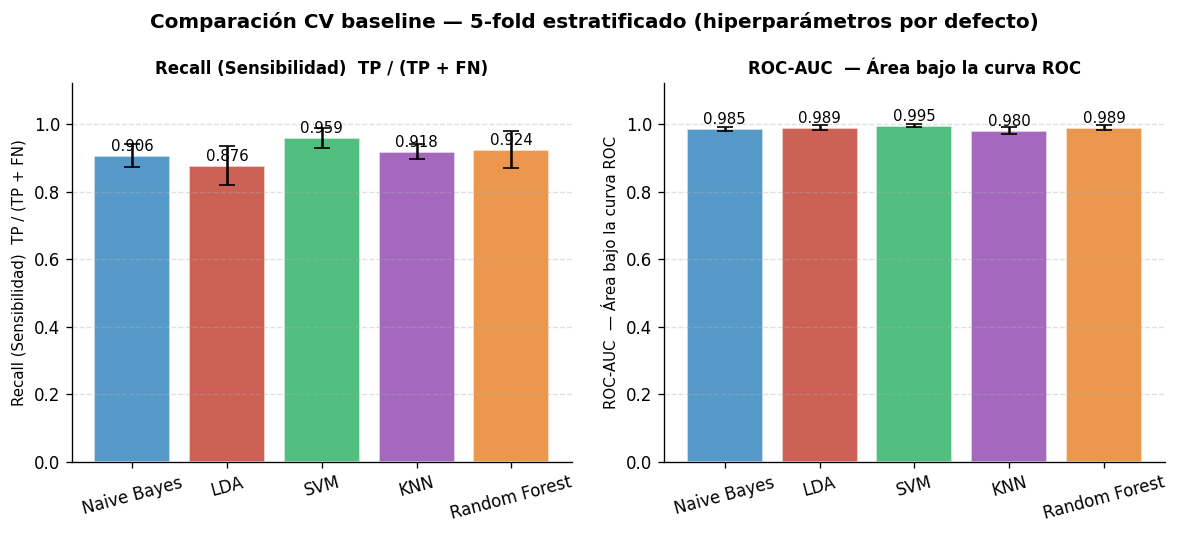

In [22]:
metrics_to_plot = ["recall", "roc_auc"]
model_names = list(cv_results.keys())
labels = [MODEL_LABELS[m] for m in model_names]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4.5))
if len(metrics_to_plot) == 1:
    axes = [axes]

colors = ["#2980B9", "#C0392B", "#27AE60", "#8E44AD", "#E67E22"]

for ax, metric in zip(axes, metrics_to_plot):
    means = [cv_results[m][f"{metric}_mean"] for m in model_names]
    stds  = [cv_results[m][f"{metric}_std"]  for m in model_names]
    bars = ax.bar(labels, means, yerr=stds, capsize=5,
                  color=colors[:len(model_names)], alpha=0.8, edgecolor="white")
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(f"Comparación CV baseline — {CV_FOLDS}-fold estratificado (hiperparámetros por defecto)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "cv_baseline_comparison.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

## Ajuste de hiperparametros -- curvas de validacion

Se generan curvas de validacion para SVM (C), KNN (k) y RF (max_depth).
Cada curva muestra train vs CV para detectar overfitting/underfitting.


--- Curvas de validacion: SVM ---


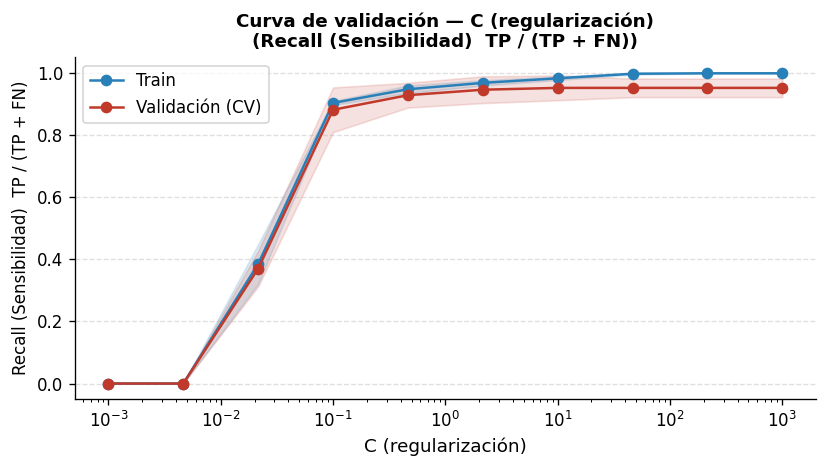


--- Curvas de validacion: KNN ---


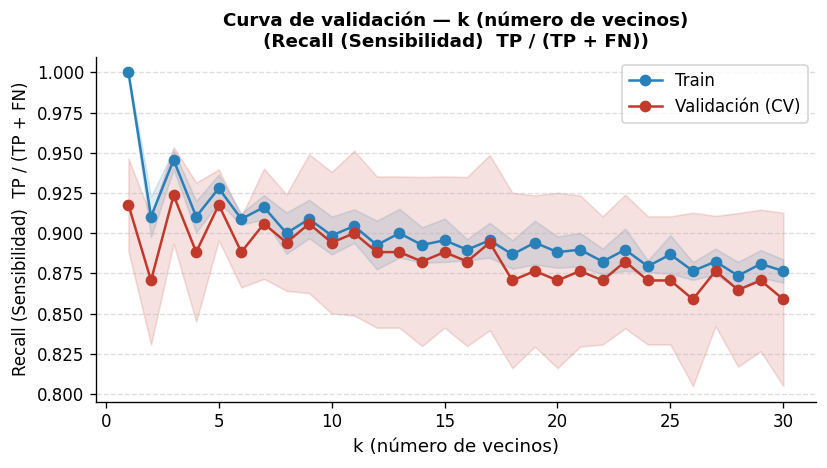


--- Curvas de validacion: Random Forest ---


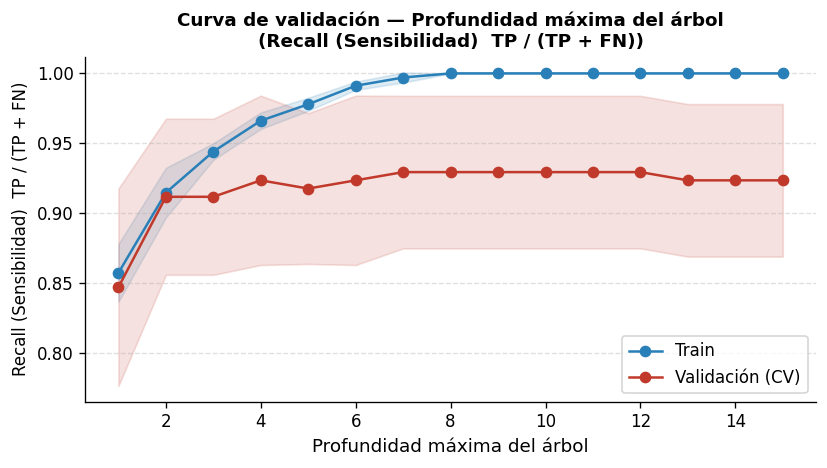

In [23]:
for model_name, curves in VALIDATION_CURVES.items():
    if model_name not in MODELS_TO_RUN:
        continue
    out_dir = ensure_output_dir(model_name)
    pipe = make_pipeline(MODEL_REGISTRY[model_name])
    print(f"\n--- Curvas de validacion: {MODEL_LABELS[model_name]} ---")
    for param_name, param_range, x_label, log_scale in curves:
        save_path = os.path.join(out_dir, f"val_curve_{x_label.replace('/', '_')}.png")
        plot_validation_curve(pipe, param_name, param_range, X_train, y_train, cv,
                              scoring="recall", x_label=x_label,
                              log_scale=log_scale, save_path=save_path)

### Búsqueda en grid 2D — combinación de hiperparámetros

Para cada modelo con múltiples hiperparámetros se corre un `GridSearchCV` exhaustivo
y se visualiza el resultado como heatmap. Cada celda muestra `mean ± std` del CV.
La mejor combinación queda enmarcada en negro.

Después de ver estos heatmaps, actualizar `BEST_PARAMS` en la celda de registro.

In [ ]:
print("Grid 2D de hiperparámetros (GridSearchCV):")
for model_name, cfg in PARAM_GRIDS_2D.items():
    if model_name not in MODELS_TO_RUN:
        continue
    out_dir = ensure_output_dir(model_name)
    print(f"\n--- {MODEL_LABELS[model_name]} ---")
    plot_hyperparam_heatmap(
        model_name, MODEL_REGISTRY[model_name], cfg,
        X_train, y_train, cv,
        scoring="recall",
        save_path=os.path.join(out_dir, "hyperparam_grid.png")
    )

## CV con mejores hiperparametros

Actualizar `BEST_PARAMS` en la celda de registro con los valores elegidos de las curvas.

In [24]:
cv_results_tuned = {}

print(f"CV tuned ({CV_FOLDS}-fold estratificado):")
for name in MODELS_TO_RUN:
    model = MODEL_REGISTRY[name]
    pipe  = make_pipeline(model)
    if name in BEST_PARAMS:
        pipe.set_params(**BEST_PARAMS[name])
    scoring = {"recall": "recall", "roc_auc": "roc_auc",
               "f1": "f1", "accuracy": "accuracy"}
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    summary = {}
    for metric in scoring:
        summary[f"{metric}_mean"] = results[f"test_{metric}"].mean()
        summary[f"{metric}_std"]  = results[f"test_{metric}"].std()
    cv_results_tuned[name] = summary
    print(f"  [{name:12s}]  recall={summary['recall_mean']:.3f}±{summary['recall_std']:.3f}  "
          f"roc_auc={summary['roc_auc_mean']:.3f}±{summary['roc_auc_std']:.3f}")

CV tuned (5-fold estratificado):
  [naive_bayes ]  recall=0.906±0.034  roc_auc=0.985±0.007
  [lda         ]  recall=0.876±0.057  roc_auc=0.989±0.008
  [svm         ]  recall=0.959±0.030  roc_auc=0.995±0.005
  [knn         ]  recall=0.906±0.034  roc_auc=0.983±0.012
  [rf          ]  recall=0.929±0.055  roc_auc=0.990±0.007


## Modelo final -- evaluacion en test

Elegir el mejor modelo (basado en recall CV), reentrenarlo sobre todo el train set
y evaluar **una sola vez** en test.

In [25]:
# Seleccion automatica por recall CV tuned
BEST_MODEL_NAME = max(cv_results_tuned, key=lambda m: cv_results_tuned[m]["recall_mean"])
print(f"Mejor modelo por recall CV: {MODEL_LABELS[BEST_MODEL_NAME]}")

# Reentrenar sobre todo el train
best_pipe = make_pipeline(MODEL_REGISTRY[BEST_MODEL_NAME])
if BEST_MODEL_NAME in BEST_PARAMS:
    best_pipe.set_params(**BEST_PARAMS[BEST_MODEL_NAME])
best_pipe.fit(X_train, y_train)

# Evaluacion en test
y_pred      = best_pipe.predict(X_test)
y_prob      = best_pipe.predict_proba(X_test)[:, 1]

test_recall  = recall_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_f1      = f1_score(y_test, y_pred)
test_acc     = accuracy_score(y_test, y_pred)

print(f"\nTest set -- {MODEL_LABELS[BEST_MODEL_NAME]}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")
print(f"  F1:        {test_f1:.4f}")
print(f"  Accuracy:  {test_acc:.4f}")

Mejor modelo por recall CV: SVM

Test set -- SVM
  Recall:    0.9286
  ROC-AUC:   0.9954
  F1:        0.9398
  Accuracy:  0.9561


### Confusion matrix + ROC del modelo final

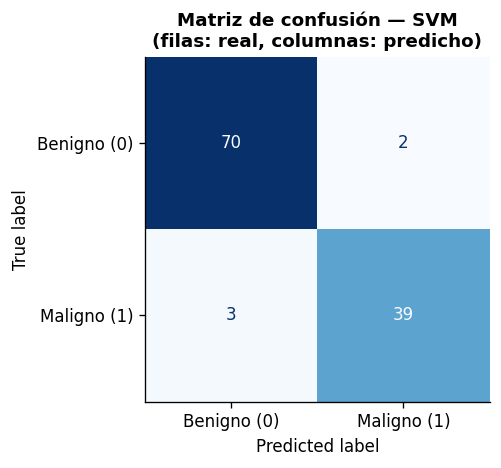

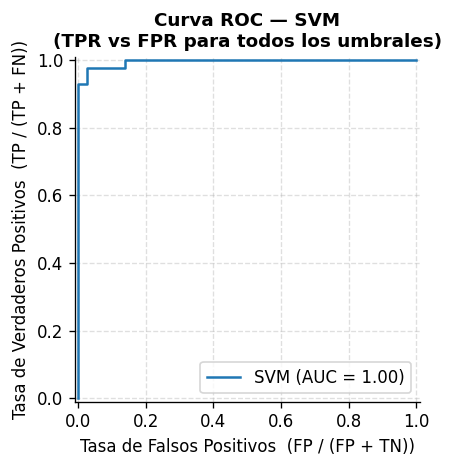

In [26]:
out_dir = ensure_output_dir(BEST_MODEL_NAME)
plot_confusion_matrix(best_pipe, X_test, y_test,
                      MODEL_LABELS[BEST_MODEL_NAME],
                      save_path=os.path.join(out_dir, "confusion_matrix_test.png"))
plot_roc_curve(best_pipe, X_test, y_test,
               MODEL_LABELS[BEST_MODEL_NAME],
               save_path=os.path.join(out_dir, "roc_curve_test.png"))

## Evaluacion en test -- todos los modelos (para comparacion final)

In [27]:
test_results = {}

for name in MODELS_TO_RUN:
    pipe = make_pipeline(MODEL_REGISTRY[name])
    if name in BEST_PARAMS:
        pipe.set_params(**BEST_PARAMS[name])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_results[name] = {
        "recall":   recall_score(y_test, y_pred),
        "roc_auc":  roc_auc_score(y_test, y_prob),
        "f1":       f1_score(y_test, y_pred),
        "accuracy": accuracy_score(y_test, y_pred),
        "pipe":     pipe,
    }
    print(f"[{name:12s}]  recall={test_results[name]['recall']:.3f}  "
          f"roc_auc={test_results[name]['roc_auc']:.3f}")

[naive_bayes ]  recall=0.881  roc_auc=0.988
[lda         ]  recall=0.881  roc_auc=0.998
[svm         ]  recall=0.929  roc_auc=0.995
[knn         ]  recall=0.810  roc_auc=0.989
[rf          ]  recall=0.881  roc_auc=0.996


### Comparacion test -- bar chart

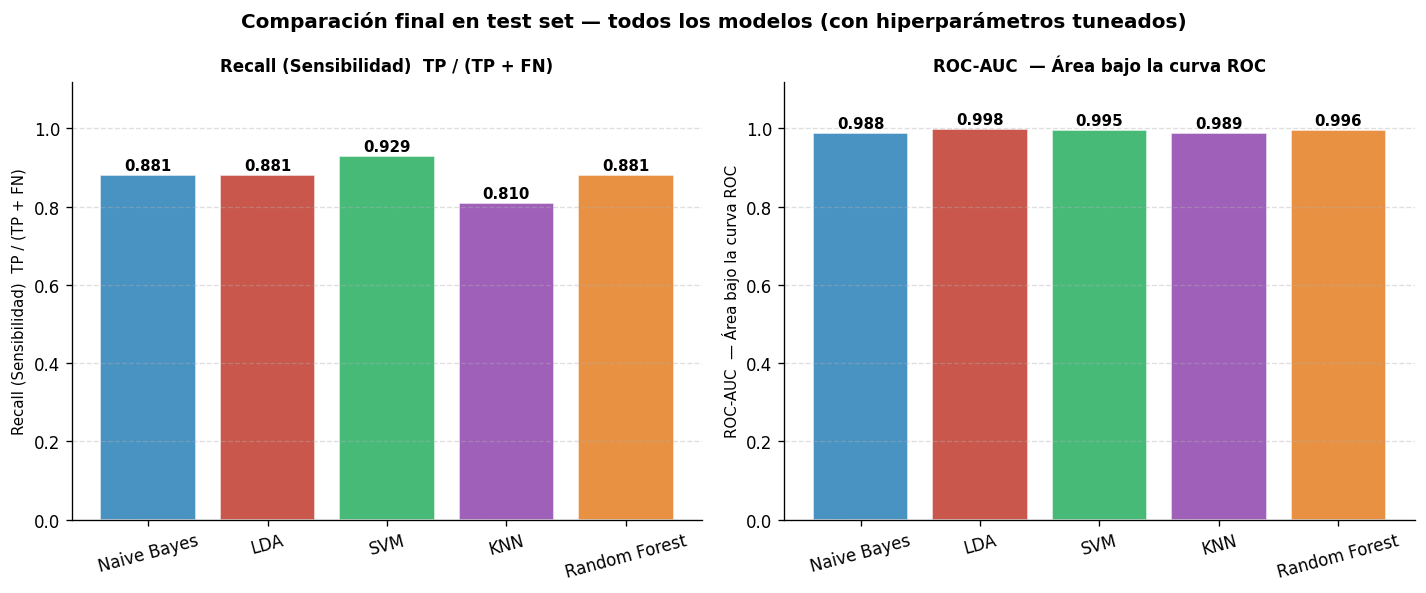

In [28]:
model_names = list(test_results.keys())
labels = [MODEL_LABELS[m] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#2980B9", "#C0392B", "#27AE60", "#8E44AD", "#E67E22"]

for ax, metric in zip(axes, ["recall", "roc_auc"]):
    vals = [test_results[m][metric] for m in model_names]
    bars = ax.bar(labels, vals, color=colors[:len(model_names)], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(METRIC_LABELS[metric], fontsize=10, fontweight="bold")
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Comparación final en test set — todos los modelos (con hiperparámetros tuneados)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "test_comparison.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

### ROC curves -- todos los modelos en un solo grafico

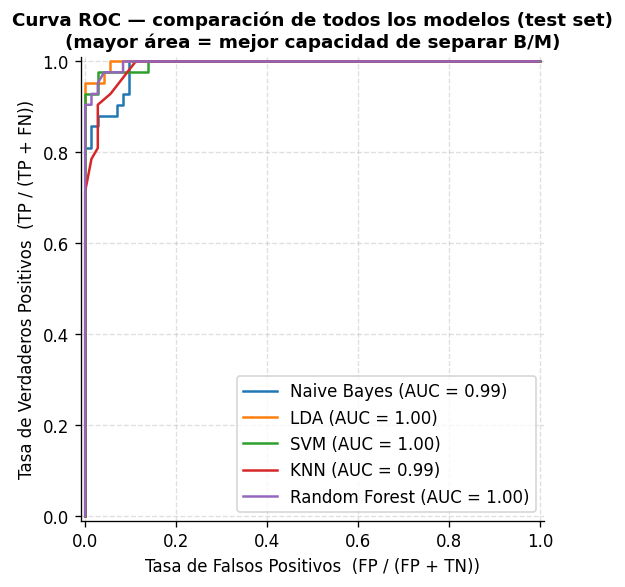

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
for name in model_names:
    plot_roc_curve(test_results[name]["pipe"], X_test, y_test,
                   MODEL_LABELS[name], ax=ax)
ax.set_title("Curva ROC — comparación de todos los modelos (test set)\n"
             "(mayor área = mejor capacidad de separar B/M)", fontsize=11, fontweight="bold")
ax.set_xlabel("Tasa de Falsos Positivos  (FP / (FP + TN))")
ax.set_ylabel("Tasa de Verdaderos Positivos  (TP / (TP + FN))")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "roc_all_models.png"), bbox_inches="tight")
plt.show()
plt.close(fig)

## Export -- graficos por modelo

Genera confusion matrix y ROC individual para cada modelo y los guarda en `outputs/{model}/`.

Exportando graficos por modelo...


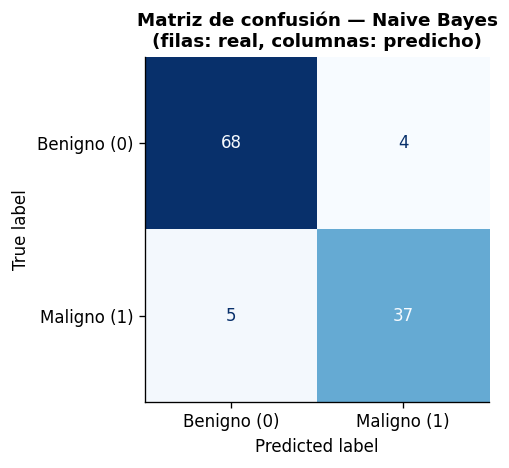

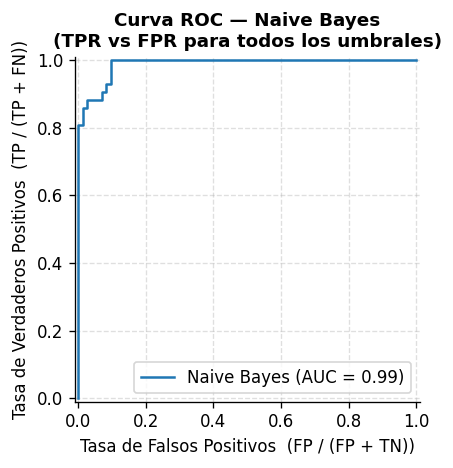

  [naive_bayes] -> outputs/naive_bayes/


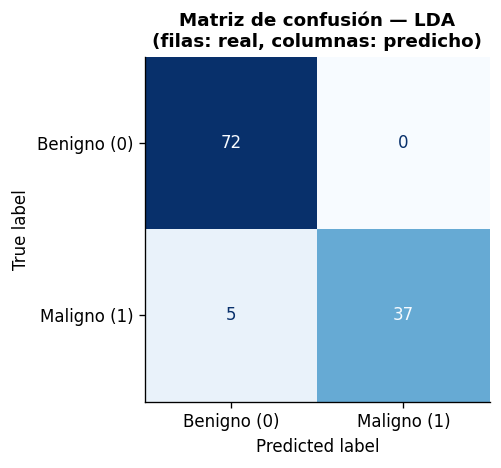

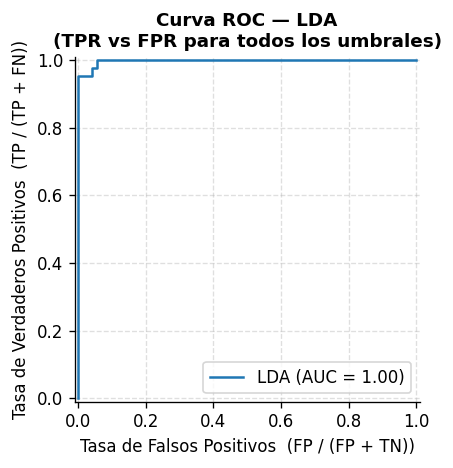

  [lda] -> outputs/lda/


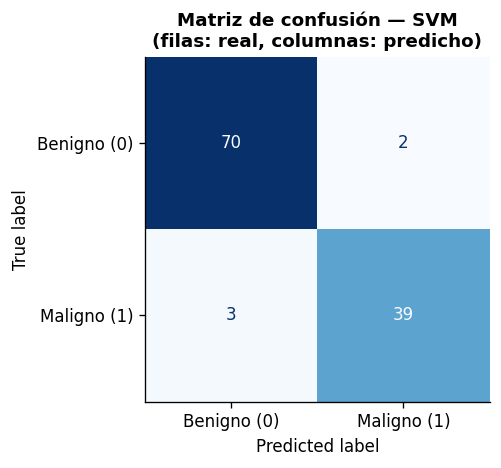

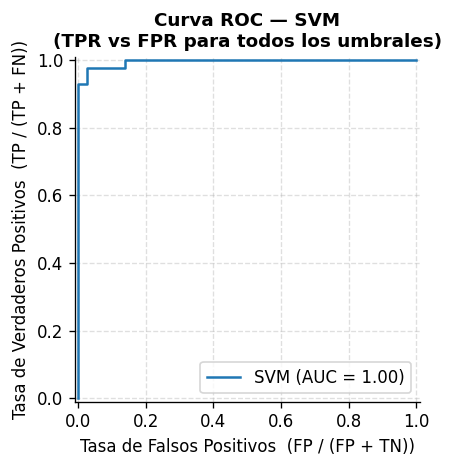

  [svm] -> outputs/svm/


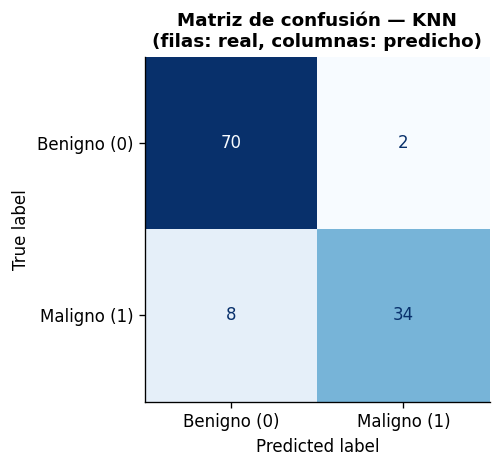

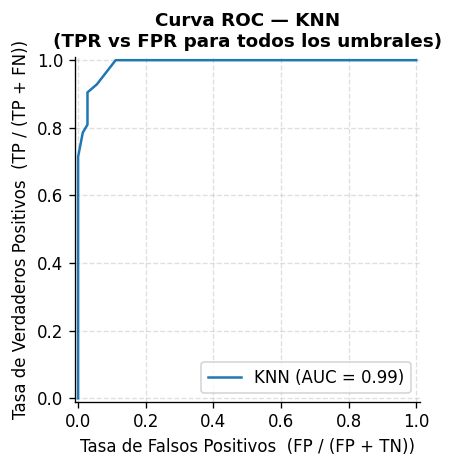

  [knn] -> outputs/knn/


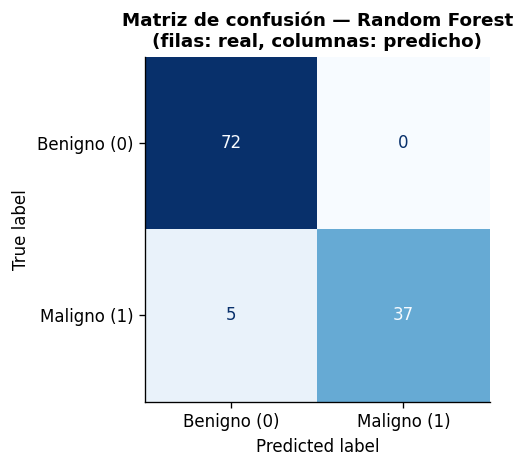

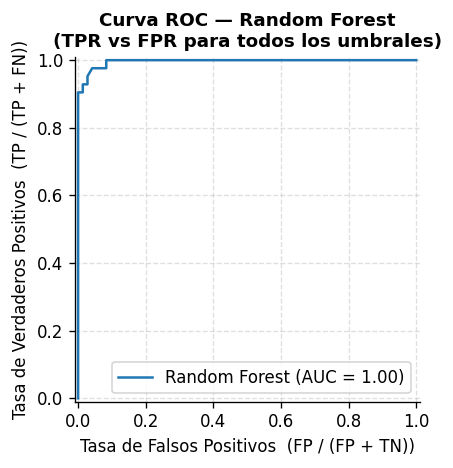

  [rf] -> outputs/rf/

Estructura outputs/
outputs/
  cv_baseline_comparison.png
  roc_all_models.png
  test_comparison.png
  svm/
    confusion_matrix.png
    confusion_matrix_test.png
    metrics.txt
    roc_curve.png
    roc_curve_test.png
    val_curve_C (regularización).png
    val_curve_C.png
  lda/
    confusion_matrix.png
    metrics.txt
    roc_curve.png
  rf/
    confusion_matrix.png
    metrics.txt
    roc_curve.png
    val_curve_Profundidad máxima del árbol.png
    val_curve_max_depth.png
  knn/
    confusion_matrix.png
    metrics.txt
    roc_curve.png
    val_curve_k (número de vecinos).png
    val_curve_k.png
  naive_bayes/
    confusion_matrix.png
    metrics.txt
    roc_curve.png


In [30]:
print("Exportando graficos por modelo...")

for name in MODELS_TO_RUN:
    out_dir = ensure_output_dir(name)
    pipe = test_results[name]["pipe"]
    label = MODEL_LABELS[name]

    # Confusion matrix
    plot_confusion_matrix(pipe, X_test, y_test, label,
                          save_path=os.path.join(out_dir, "confusion_matrix.png"))

    # ROC individual
    plot_roc_curve(pipe, X_test, y_test, label,
                   save_path=os.path.join(out_dir, "roc_curve.png"))

    # Metricas en texto
    with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
        f.write(f"Model: {label}\n")
        for metric in ["recall", "roc_auc", "f1", "accuracy"]:
            cv_key = f"{metric}_mean"
            cv_val = cv_results_tuned.get(name, {}).get(cv_key, float("nan"))
            test_val = test_results[name][metric]
            f.write(f"{metric:12s}  cv={cv_val:.4f}  test={test_val:.4f}\n")

    print(f"  [{name}] -> {out_dir}/")

print("\nEstructura outputs/")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in sorted(files):
        print(f"{indent}  {file}")